<a href="https://colab.research.google.com/github/MaksimObukhov/human-activity-recognition/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PV056 — Topic 1: Human Activity Recognition

Dataset: UCI HAR (smartphone inertial sensors)  
Goal: classify 6 activities; beat LSTM baseline (F1-macro > 0.80)

**General (every topic):**

- R1a — visualize class label distribution
- R1b — find/visualize outliers or anomalies
- R2a — use HPO (hyperparameter optimization) to find hyperparameters
- R2b — visualize training progress, train to convergence
- R3a — explore successful/failed cases (confusion matrix, explainability)
- R3b — present results in a suitable form

**Topic 1 specific:**
- T1a — data analysis to uncover tough cases (e.g. T-SNE, error analysis, sequence patterns like "does sitting→climbing stairs co-occur?")
- T1b — improve over the given LSTM baseline (~0.80 F1-macro)

## 1. Setup & Data Loading

In [ ]:
!pip install optuna
!pip install torch
!pip install xgboost==2.0.3
!pip install scikit-learn==1.4.2

In [ ]:
!pip install kaggle

In [ ]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])? y


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn
import sklearn as sk
import torch
import optuna
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d uciml/human-activity-recognition-with-smartphones -p data --unzip

Dataset URL: https://www.kaggle.com/datasets/uciml/human-activity-recognition-with-smartphones
License(s): CC0-1.0
100% 24.5M/24.5M [00:02<00:00, 11.2MB/s]



In [ ]:
import os
print(os.listdir("data"))

['train.csv', 'test.csv']


In [ ]:
df_train = pd.read_csv("./data/train.csv")
df_test = pd.read_csv("./data/test.csv")

print(df_train.shape, df_test.shape)

(7352, 563) (2947, 563)


In [ ]:
df_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [ ]:
df_test.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2,STANDING
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2,STANDING
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2,STANDING
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,2,STANDING
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,2,STANDING


## 2. [R1a] Class Label Distribution

In [ ]:
df_train['Activity'].value_counts()

,count
Activity,
LAYING,1407
STANDING,1374
SITTING,1286
WALKING,1226
WALKING_UPSTAIRS,1073
WALKING_DOWNSTAIRS,986


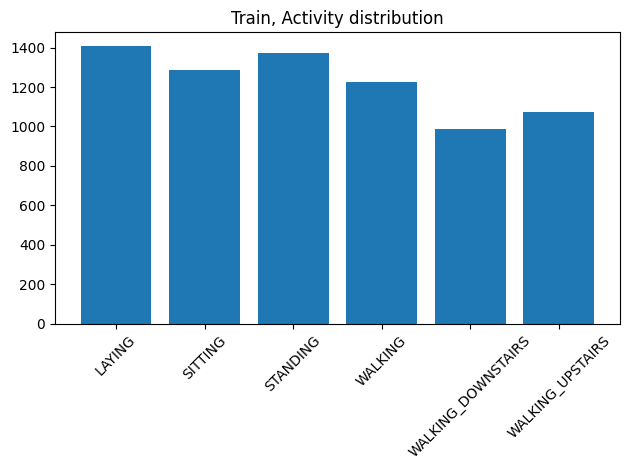

In [ ]:
counts = df_train['Activity'].value_counts().sort_index()
plt.bar(counts.index, counts.values)
plt.title('Train, Activity distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
df_test['Activity'].value_counts()

,count
Activity,
LAYING,537
STANDING,532
WALKING,496
SITTING,491
WALKING_UPSTAIRS,471
WALKING_DOWNSTAIRS,420


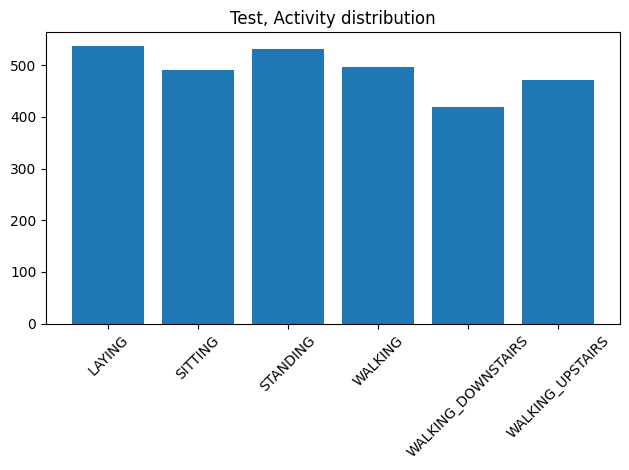

In [ ]:
counts = df_test['Activity'].value_counts().sort_index()
plt.bar(counts.index, counts.values)
plt.title('Test, Activity distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
df_train['subject'].value_counts()

,count
subject,
25,409
21,408
26,392
30,383
28,382
27,376
23,372
17,368
16,366


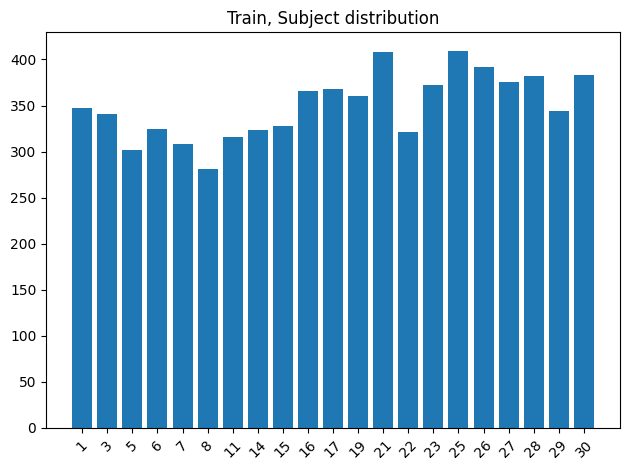

In [ ]:
counts = df_train['subject'].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.title('Train, Subject distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Some subjects are missing in train.

Missing: 2, 4, 9, 10, 12, 13, 18, 20, 24

In [ ]:
df_test['subject'].value_counts()

,count
subject,
24,381
18,364
20,354
13,327
12,320
4,317
2,302
10,294
9,288


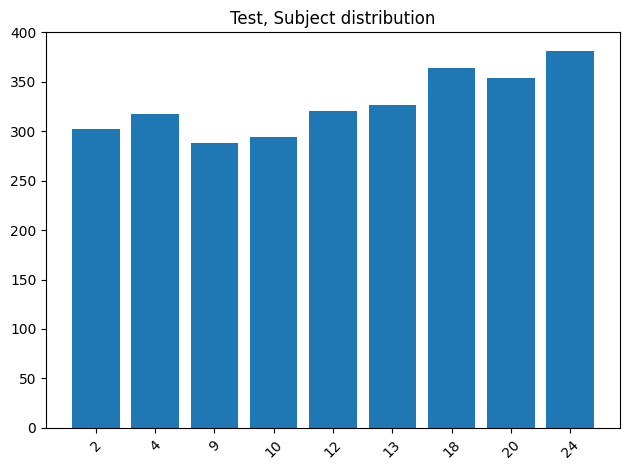

In [ ]:
counts = df_test['subject'].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.title('Test, Subject distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Missing subjects are found in test!

### **Notice that subjects in train and test are not the same!**

Test complements the train, be aware of that.

# Build baseline first

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

LABEL_COL = 'Activity'
DROP_COLS = ['Activity', 'subject']

X_train = df_train.drop(columns=DROP_COLS).values
y_train = df_train[LABEL_COL].values
X_test  = df_test.drop(columns=DROP_COLS).values
y_test  = df_test[LABEL_COL].values

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_s, y_train)
print(f'LR   F1-macro: {f1_score(y_test, lr.predict(X_test_s), average="macro"):.4f}')

# Random Forest (tree-based, no scaling needed)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(f'RF   F1-macro: {f1_score(y_test, rf.predict(X_test), average="macro"):.4f}')

print('Baseline target: 0.80')


LR   F1-macro: 0.9550
RF   F1-macro: 0.9245
Baseline target: 0.80


In [ ]:
from sklearn.metrics import classification_report

print("=== Logistic Regression ===")
print(classification_report(y_test, lr.predict(X_test_s)))

print("=== Random Forest ===")
print(classification_report(y_test, rf.predict(X_test)))


=== Logistic Regression ===
                    precision    recall  f1-score   support

            LAYING       1.00      0.99      1.00       537
           SITTING       0.97      0.88      0.92       491
          STANDING       0.89      0.97      0.93       532
           WALKING       0.94      0.99      0.97       496
WALKING_DOWNSTAIRS       0.99      0.94      0.96       420
  WALKING_UPSTAIRS       0.96      0.95      0.95       471

          accuracy                           0.96      2947
         macro avg       0.96      0.95      0.95      2947
      weighted avg       0.96      0.96      0.96      2947

=== Random Forest ===
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.89      0.90       491
          STANDING       0.90      0.92      0.91       532
           WALKING       0.89      0.97      0.93       496
WALKING_DOWNSTAIRS       0.97      0.87      0

Results are quite surprising. Classical feature engineering + simple classifier outperforms a naive deep learning baseline. Im continuing with performing required steps and would try to improve the baseline

## 3. [R1b] Outlier / Anomaly Detection

Implementing PCA

In [ ]:
from sklearn.decomposition import PCA

N_COMPONENTS = 50

pca = PCA(n_components=N_COMPONENTS)
X_train_pca = pca.fit_transform(X_train_s)
X_train_reconstructed = pca.inverse_transform(X_train_pca)

reconstruction_errors = np.mean((X_train_s - X_train_reconstructed) ** 2, axis=1)


In [ ]:
threshold = np.percentile(reconstruction_errors, 95)
outlier_mask = reconstruction_errors > threshold

print(f'Outliers detected: {outlier_mask.sum()} ({outlier_mask.mean()*100:.1f}%)')


Outliers detected: 368 (5.0%)


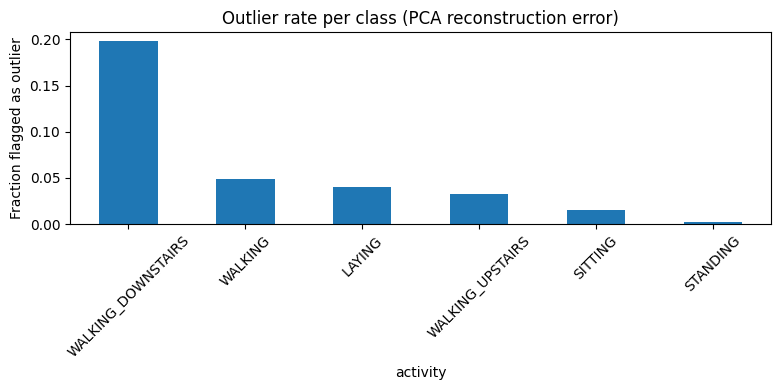

In [ ]:
outlier_df = pd.DataFrame({
    'activity': y_train,
    'error': reconstruction_errors,
    'is_outlier': outlier_mask
})

outlier_rate = outlier_df.groupby('activity')['is_outlier'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
outlier_rate.plot(kind='bar')
plt.title('Outlier rate per class (PCA reconstruction error)')
plt.ylabel('Fraction flagged as outlier')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Results look logically. Standing data is quite the same in time, while walking downstairs makes hand move up and down intensively. We come back to it at the end.

## 4. [T1a] Tough Case Analysis

Be aware of differences between subject behaviours within the same class. Visualise per-subject variation within a class.

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_jobs=-1)
X_2d = tsne.fit_transform(X_train_s)

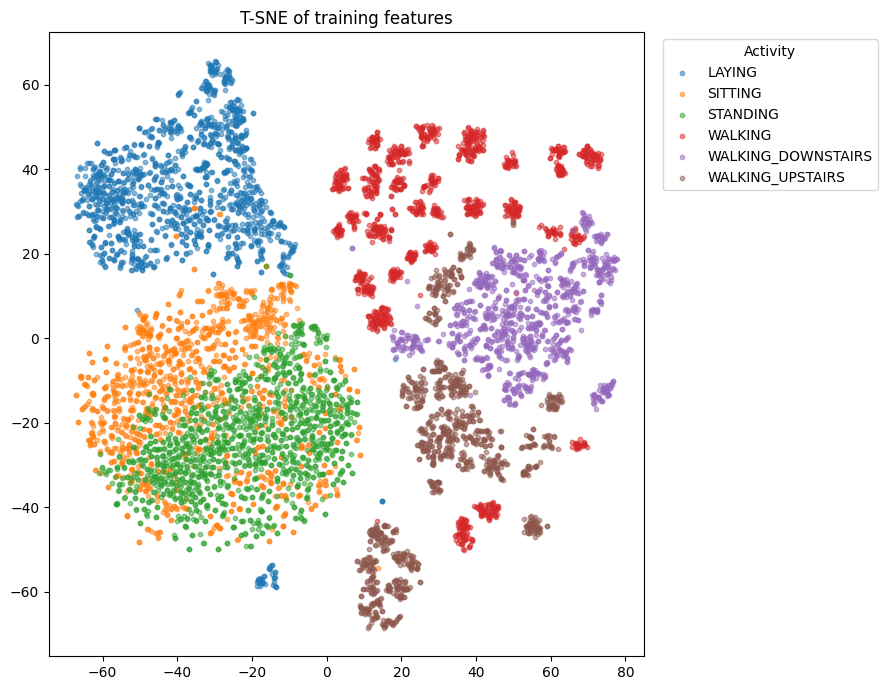

In [ ]:
plt.figure(figsize=(9, 7))
for activity in np.unique(y_train):
    mask = y_train == activity
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=activity, alpha=0.5, s=10)
plt.legend(title='Activity', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title('T-SNE of training features')
plt.tight_layout()
plt.show()


walking  downstairs has a dense cluster, sitting and standing are quite mixxed up, sounds logically. Laying has its dense cluster as well. Walking has many small clusters, which may sign how people walk differently.

Interesting that T-SNE reveals two distinct regions: static activities (sitting, standing) form an overlapping cluster, while dynamic activities (waling variants) form separate but neighbouring sub-clusters. This explains the lower F1 scores for sitting and standing.

## 5. [R2a/R2b/T1b] Models, HPO, Training

When test different models, be aware of they might require different dataset preparation.
For example XGBoost (doesn't care about scaling (splits are based on rank/thresholds, not distances) vs Neural Networks (care a lot, unscaled features with very different ranges will make training unstable)

**Does the order of windows matter, and how do different models handle (or ignore) that sequence?**
That's the core difference between throwing XGBoost at it vs using an LSTM.

Let's try to implement and evaluate 4 models: XGBoost, SVM, LSTM and Transformer

### 1. XGBoost

In [ ]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)


In [ ]:
from sklearn.model_selection import cross_val_score
import xgboost as xgb
import optuna

def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'tree_method': 'hist',
        'eval_metric': 'mlogloss',
        'random_state': 42,
        'n_jobs': 1   # ✅ IMPORTANT FIX
    }

    model = xgb.XGBClassifier(**params)

    scores = cross_val_score(
        model,
        X_train,
        y_train_enc,
        cv=3,
        scoring='f1_macro',
        n_jobs=1   # ✅ IMPORTANT FIX
    )

    return scores.mean()

study_xgb = optuna.create_study(direction='maximize')

study_xgb.optimize(
    xgb_objective,
    n_trials=20,   # ✅ reduced for speed (you can go back to 30 later)
    show_progress_bar=True
)

print('Best F1-macro:', study_xgb.best_value)
print('Best params:', study_xgb.best_params)


[I 2026-04-16 15:21:13,248] A new study created in memory with name: no-name-965fa4df-dd5b-43fc-8424-f2bd6677030d


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-16 15:23:18,997] Trial 0 finished with value: 0.9128379998045872 and parameters: {'n_estimators': 250, 'max_depth': 3, 'learning_rate': 0.03439280110225138, 'subsample': 0.7055996863146952, 'colsample_bytree': 0.9837355622178746}. Best is trial 0 with value: 0.9128379998045872.
[I 2026-04-16 15:25:08,723] Trial 1 finished with value: 0.8954978969885805 and parameters: {'n_estimators': 195, 'max_depth': 4, 'learning_rate': 0.018663703194217847, 'subsample': 0.7865078582699616, 'colsample_bytree': 0.8549303901786476}. Best is trial 0 with value: 0.9128379998045872.
[I 2026-04-16 15:25:52,672] Trial 2 finished with value: 0.9080351542544453 and parameters: {'n_estimators': 112, 'max_depth': 3, 'learning_rate': 0.06304887131755763, 'subsample': 0.9117167793013168, 'colsample_bytree': 0.6788165109791191}. Best is trial 0 with value: 0.9128379998045872.
[I 2026-04-16 15:28:19,970] Trial 3 finished with value: 0.9056880993458359 and parameters: {'n_estimators': 257, 'max_depth': 4,

### 2. SVM

In [ ]:
def svm_objective(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 100, log=True),
        'kernel': trial.suggest_categorical('kernel', ['rbf', 'linear']),
        'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
    }
    model = SVC(**params)
    scores = cross_val_score(model, X_train_s, y_train, cv=3, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(svm_objective, n_trials=20, show_progress_bar=True)
print('SVM Best F1-macro:', study_svm.best_value)
print('Best params:', study_svm.best_params)


[I 2026-04-16 15:50:19,211] A new study created in memory with name: no-name-051307fa-680f-42ce-a2b1-cee70e266475


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-16 15:50:22,616] Trial 0 finished with value: 0.9397874117055034 and parameters: {'C': 0.5345553943801736, 'kernel': 'linear', 'gamma': 'auto'}. Best is trial 0 with value: 0.9397874117055034.
[I 2026-04-16 15:50:27,280] Trial 1 finished with value: 0.9290647380251063 and parameters: {'C': 20.58129363905915, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: 0.9397874117055034.
[I 2026-04-16 15:50:32,359] Trial 2 finished with value: 0.928588826998431 and parameters: {'C': 3.183073210068741, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: 0.9397874117055034.
[I 2026-04-16 15:50:34,356] Trial 3 finished with value: 0.9389070006936179 and parameters: {'C': 0.26903330775295536, 'kernel': 'linear', 'gamma': 'auto'}. Best is trial 0 with value: 0.9397874117055034.
[I 2026-04-16 15:50:35,784] Trial 4 finished with value: 0.9390252160248861 and parameters: {'C': 1.1243246876817152, 'kernel': 'linear', 'gamma': 'scale'}. Best is trial 0 with value: 0.939

### 3. LSTM

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', DEVICE)

X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32)
y_train_t = torch.tensor(y_train_enc, dtype=torch.long)
y_test_t  = torch.tensor(y_test_enc,  dtype=torch.long)

class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout, n_classes):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden_size, n_classes))

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

def train_and_eval(model, X_tr, y_tr, X_te, y_te, lr, epochs, batch_size):
    dl = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.to(DEVICE)
    for _ in range(epochs):
        model.train()
        for Xb, yb in dl:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            criterion(model(Xb), yb).backward()
            opt.step()
    model.eval()
    with torch.no_grad():
        preds = model(X_te.to(DEVICE)).argmax(1).cpu().numpy()
    return f1_score(y_te.numpy(), preds, average='macro')

def lstm_objective(trial):
    hidden = trial.suggest_categorical('hidden_size', [64, 128, 256])
    layers = trial.suggest_int('num_layers', 1, 3)
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    bs = trial.suggest_categorical('batch_size', [64, 128])

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_s, y_train_enc, test_size=0.2, random_state=42, stratify=y_train_enc
    )

    X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.long)
    y_val_t = torch.tensor(y_val, dtype=torch.long)

    model = LSTMClassifier(X_train_s.shape[1], hidden, layers, dropout, len(le.classes_))
    return train_and_eval(model,
                          X_tr_t.unsqueeze(1), y_tr_t,
                          X_val_t.unsqueeze(1), y_val_t,
                          lr=lr, epochs=20, batch_size=bs)

study_lstm = optuna.create_study(direction='maximize')
study_lstm.optimize(lstm_objective, n_trials=20, show_progress_bar=True)
print('LSTM Best F1-macro:', study_lstm.best_value)
print('LSTM Best params:', study_lstm.best_params)


[I 2026-04-16 15:51:24,948] A new study created in memory with name: no-name-6fc0ee57-04a5-4281-a11c-1480a62ec587


Device: cpu


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-16 15:51:44,789] Trial 0 finished with value: 0.9810005595615549 and parameters: {'hidden_size': 128, 'num_layers': 3, 'dropout': 0.19800298204894728, 'lr': 0.0003471218998440717, 'batch_size': 128}. Best is trial 0 with value: 0.9810005595615549.
[I 2026-04-16 15:52:22,798] Trial 1 finished with value: 0.9853955448892157 and parameters: {'hidden_size': 256, 'num_layers': 2, 'dropout': 0.3613194197239521, 'lr': 0.004823475464257429, 'batch_size': 64}. Best is trial 1 with value: 0.9853955448892157.
[I 2026-04-16 15:52:49,408] Trial 2 finished with value: 0.9843158342855863 and parameters: {'hidden_size': 256, 'num_layers': 2, 'dropout': 0.11763351092481776, 'lr': 0.0001770293166817785, 'batch_size': 128}. Best is trial 1 with value: 0.9853955448892157.
[I 2026-04-16 15:53:13,961] Trial 3 finished with value: 0.9858327271438032 and parameters: {'hidden_size': 256, 'num_layers': 1, 'dropout': 0.47387553803418536, 'lr': 0.0012146087024145315, 'batch_size': 64}. Best is trial 3 

Looks like the feature engineering is the bottleneck, not the model complexity. Every model F1-score is around 0.95-0.96

## Retrain models on the best params

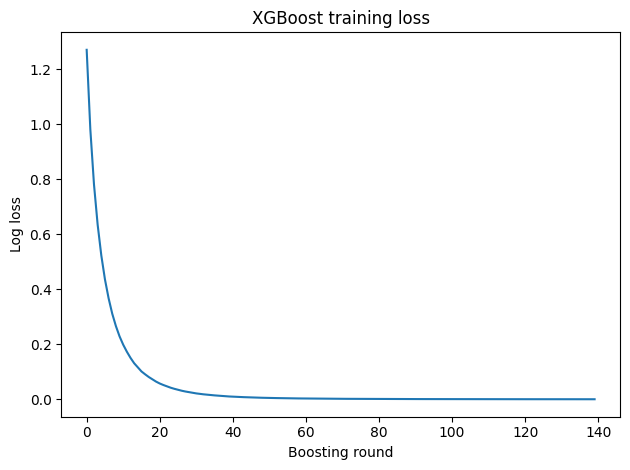

In [ ]:
best_xgb = xgb.XGBClassifier(**study_xgb.best_params, tree_method='hist', random_state=42)
best_xgb.fit(
    X_train, y_train_enc,
    eval_set=[(X_train, y_train_enc)],
    verbose=False
)

results = best_xgb.evals_result()
plt.plot(results['validation_0']['mlogloss'])
plt.title('XGBoost training loss')
plt.xlabel('Boosting round')
plt.ylabel('Log loss')
plt.tight_layout()
plt.show()

In [ ]:
xgb_f1 = f1_score(y_test_enc, best_xgb.predict(X_test), average='macro')
print(f'XGBoost final F1-macro: {xgb_f1:.4f}')


XGBoost final F1-macro: 0.9478


In [ ]:
from sklearn.svm import SVC

best_svm = SVC(**study_svm.best_params)
best_svm.fit(X_train_s, y_train)
svm_f1 = f1_score(y_test, best_svm.predict(X_test_s), average='macro')
print(f'SVM final F1-macro: {svm_f1:.4f}')


SVM final F1-macro: 0.9598


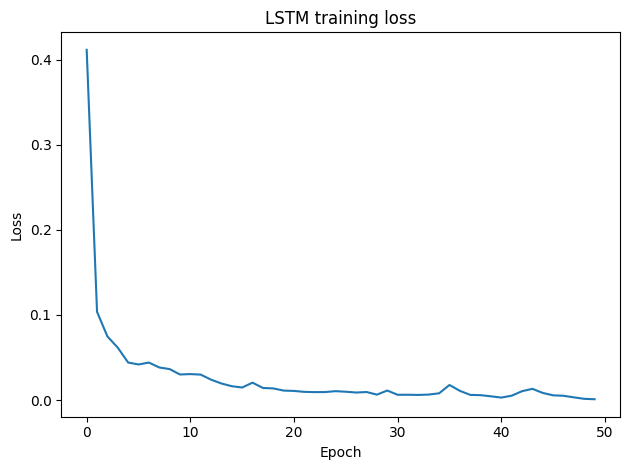

In [ ]:
best_lstm_params = study_lstm.best_params

best_lstm_model = LSTMClassifier(
    input_size=X_train_s.shape[1],
    hidden_size=best_lstm_params['hidden_size'],
    num_layers=best_lstm_params['num_layers'],
    dropout=best_lstm_params['dropout'],
    n_classes=len(le.classes_)
).to(DEVICE)

dl = DataLoader(
    TensorDataset(X_train_t.unsqueeze(1), y_train_t),
    batch_size=best_lstm_params['batch_size'],
    shuffle=True
)

opt = torch.optim.Adam(best_lstm_model.parameters(), lr=best_lstm_params['lr'])
criterion = nn.CrossEntropyLoss()

train_losses = []

for epoch in range(50):
    best_lstm_model.train()
    epoch_loss = 0
    for Xb, yb in dl:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        loss = criterion(best_lstm_model(Xb), yb)
        loss.backward()
        opt.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(dl))

plt.plot(train_losses)
plt.title('LSTM training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()


In [ ]:
best_lstm_model.eval()
with torch.no_grad():
    lstm_preds = best_lstm_model(X_test_t.unsqueeze(1).to(DEVICE)).argmax(1).cpu().numpy()
lstm_f1 = f1_score(y_test_enc, lstm_preds, average='macro')
print(f'LSTM final F1-macro: {lstm_f1:.4f}')


LSTM final F1-macro: 0.9487


## 6. [R3a/R3b] Results & Analysis

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(colorbar=False, cmap='Blues', xticks_rotation=30)
    plt.title(title)
    plt.tight_layout()
    plt.show()



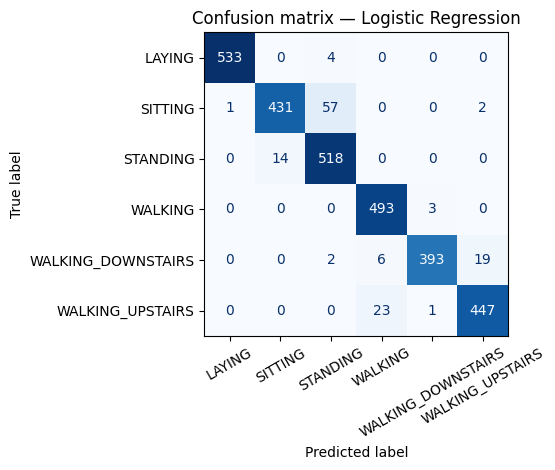

In [ ]:
plot_cm(y_test, lr.predict(X_test_s), 'Confusion matrix — Logistic Regression')


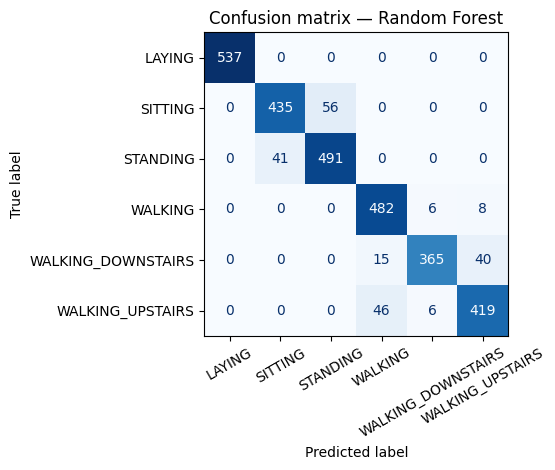

In [ ]:
plot_cm(y_test, rf.predict(X_test), 'Confusion matrix — Random Forest')


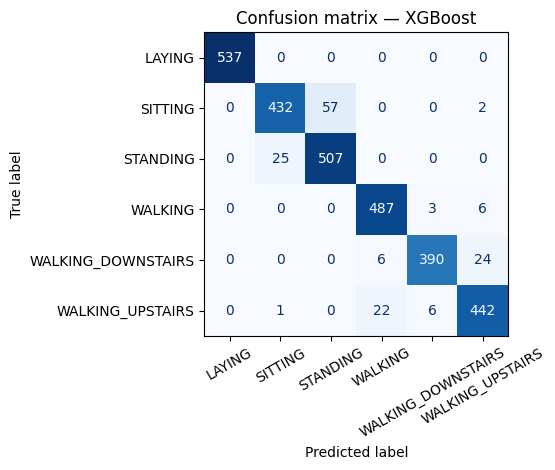

In [ ]:
plot_cm(y_test, le.inverse_transform(best_xgb.predict(X_test)), 'Confusion matrix — XGBoost')


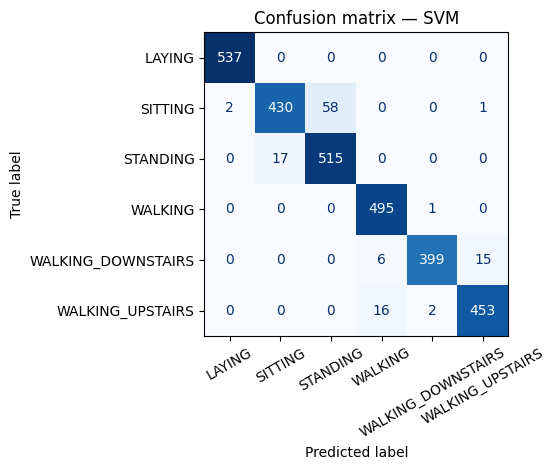

In [ ]:
best_svm = SVC(**study_svm.best_params)
best_svm.fit(X_train_s, y_train)
y_pred_svm = best_svm.predict(X_test_s)

plot_cm(y_test, y_pred_svm, 'Confusion matrix — SVM')


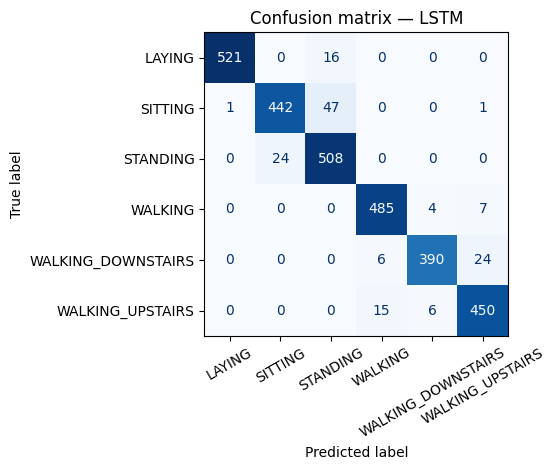

In [ ]:
plot_cm(y_test, le.inverse_transform(lstm_preds), 'Confusion matrix — LSTM')


### Results table

In [ ]:
results = pd.DataFrame([
    {'Model': 'Naive LSTM baseline', 'F1-macro': 0.800},
    {'Model': 'Random Forest', 'F1-macro': f1_score(y_test, rf.predict(X_test), average='macro')},
    {'Model': 'LSTM (HPO)', 'F1-macro': f1_score(y_test, le.inverse_transform(lstm_preds), average='macro')},
    {'Model': 'Logistic Regression', 'F1-macro': f1_score(y_test, lr.predict(X_test_s), average='macro')},
    {'Model': 'XGBoost (HPO)', 'F1-macro': f1_score(y_test, le.inverse_transform(best_xgb.predict(X_test)), average='macro')},
    {'Model': 'SVM (HPO)', 'F1-macro': f1_score(y_test, y_pred_svm, average='macro')},
]).sort_values('F1-macro')

print(results.to_string(index=False))


              Model  F1-macro
Naive LSTM baseline  0.800000
      Random Forest  0.924489
      XGBoost (HPO)  0.947808
         LSTM (HPO)  0.948743
Logistic Regression  0.954965
          SVM (HPO)  0.959840


### Overlap misclassified on T-SNE

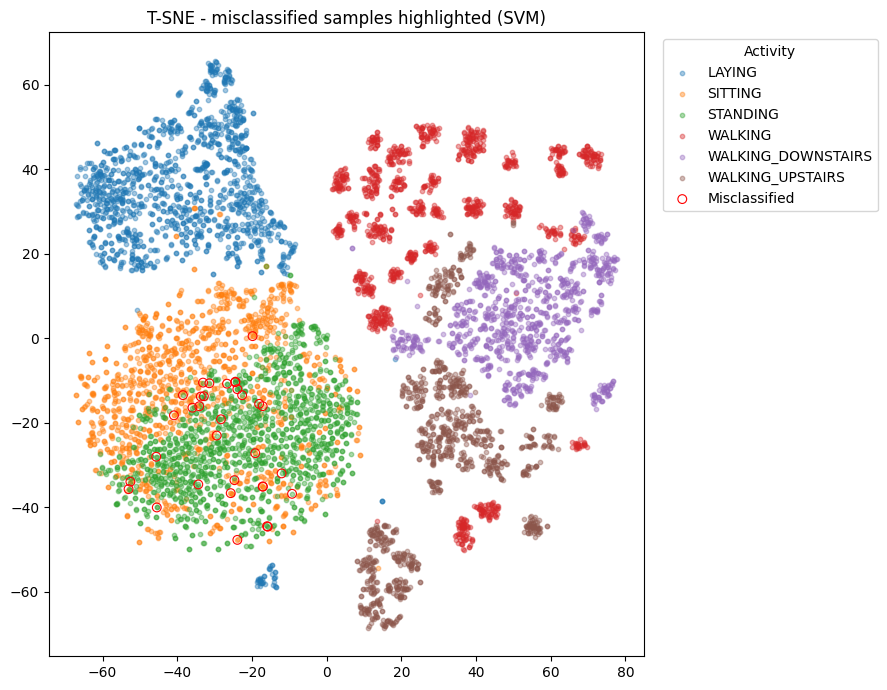

In [ ]:
svm_train_preds = best_svm.predict(X_train_s)
misclassified = svm_train_preds != y_train

plt.figure(figsize=(9, 7))
for activity in np.unique(y_train):
    mask = y_train == activity
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=activity, alpha=0.4, s=10)

# Overlay misclassified points
plt.scatter(X_2d[misclassified, 0], X_2d[misclassified, 1],
            facecolors='none', edgecolors='red', s=40, linewidths=0.8, label='Misclassified')

plt.legend(title='Activity', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title('T-SNE - misclassified samples highlighted (SVM)')
plt.tight_layout()
plt.show()


Interesting the misclassified items are in the SITTING/STANDING overlap region

### Feature importance (XGBoost)

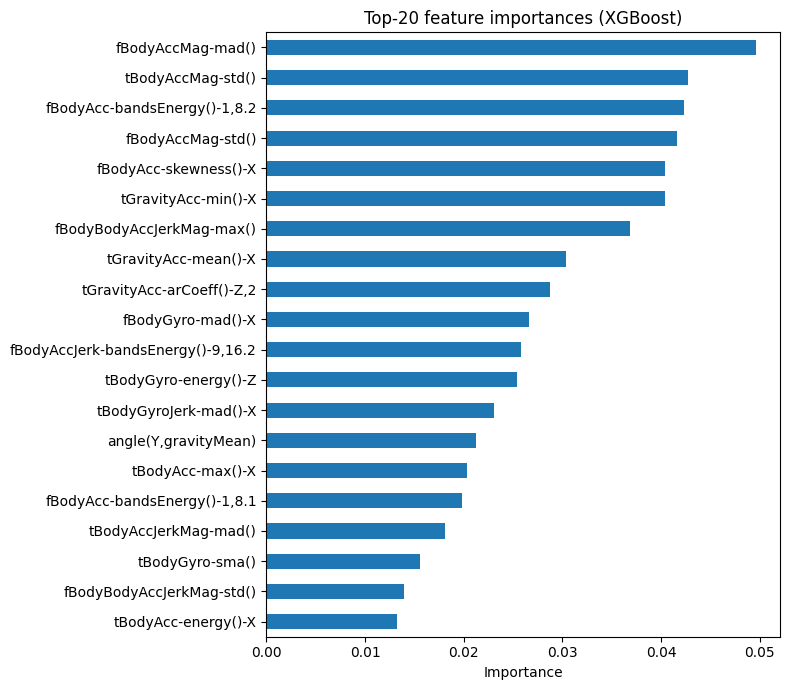

In [ ]:
importances = pd.Series(best_xgb.feature_importances_,
                        index=df_train.drop(columns=['Activity', 'subject']).columns)
top20 = importances.nlargest(20).sort_values()

top20.plot(kind='barh', figsize=(8, 7), title='Top-20 feature importances (XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
